In [1]:
# %pip install bt pandas numpy matplotlib polars mlforecast

In [2]:
# %pip install hyperopt

In [3]:
# %pip install numpy==1.25.2 pandas==2.0.3 gym_mtsim

In [4]:
# import MetaTrader5 as mt5

# # Replace with your MT5 account details
# login = 7415336834  # Your MT5 account number
# password = "9o4OklPx@FUN7020"  # Your MT5 account password
# server = "Wealthway-Demo"  # Your broker's MT5 server address (e.g., "MetaQuotes-Demo")

# # Initialize the connection
# if not mt5.initialize():
#     print("initialize() failed, error code =", mt5.last_error())
#     mt5.shutdown()
#     quit()

# # Attempt to login
# authorized = mt5.login(login, password=password, server=server)
# if authorized:
#     print("Connected to MT5 account #", login)
#     # Your trading logic goes here
# else:
#     print("Failed to connect to MT5 account #", login, ", error code =", mt5.last_error())
#     mt5.shutdown()
#     quit()

# # Shut down the connection when done
# mt5.shutdown()

In [5]:
import numpy as np
print(np.__version__)
import pandas as pd
print(pd.__version__)

1.25.2
2.0.3


In [6]:
import pandas as pd
import numpy as np
import polars as pl
import pickle
import sys
sys.path.append("C:/Users/WilliamFetzner/Documents/Trading/")
from gym_mtsim_forked.gym_mtsim.data import FOREX_DATA_PATH, FOREX_DATA_PATH_15MIN
import pytz
from datetime import datetime, timedelta, time
from gym_mtsim import MtSimulator, OrderType, Order, OrderNotFound
from functools import partial
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials, STATUS_FAIL
from typing import Dict
from ydata_profiling import ProfileReport
from dateutil.relativedelta import relativedelta

c:\Users\WilliamFetzner\Documents\Trading\Indicator_backtesting\Indicator_search\indicatorSearch\Lib\site-packages\gymnasium\envs\registration.py:642: UserWarning: WARN: Overriding environment forex-hedge-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\WilliamFetzner\Documents\Trading\Indicator_backtesting\Indicator_search\indicatorSearch\Lib\site-packages\gymnasium\envs\registration.py:642: UserWarning: WARN: Overriding environment forex-unhedge-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\WilliamFetzner\Documents\Trading\Indicator_backtesting\Indicator_search\indicatorSearch\Lib\site-packages\gymnasium\envs\registration.py:642: UserWarning: WARN: Overriding environment stocks-hedge-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
c:\Users\WilliamFetzner\Documents\Trading\Indicator_backtesting\Indicator_search\i

In [7]:
path_to_trading_folder = 'C:/Users/WilliamFetzner/Documents/Trading/'
# data_path = 'EURUSD_full_tickstory_data_15_min.csv'
data_path = 'EURUSD_full_tickstory_data_hourly.csv'

In [8]:
with open(FOREX_DATA_PATH_15MIN, 'rb') as f:
    symbols_1hr = pickle.load(f)
# convert symbols_1hr to a pd.dataframe
symbols_1hr[1]['EURUSD'].index = pd.to_datetime(symbols_1hr[1]['EURUSD'].index)
full_data = symbols_1hr[1]['EURUSD']
# full_data.columns = full_data.columns.str.lower()
full_data

,Open,High,Low,Close
Time,,,,
2023-08-09 23:45:00,1.09721,1.09741,1.09720,1.09734
2023-08-10 00:00:00,1.09733,1.09783,1.09725,1.09743
2023-08-10 00:15:00,1.09743,1.09754,1.09735,1.09754
2023-08-10 00:30:00,1.09753,1.09754,1.09735,1.09741
2023-08-10 00:45:00,1.09742,1.09768,1.09741,1.09763
...,...,...,...,...
2024-08-09 22:45:00,1.09183,1.09189,1.09179,1.09187
2024-08-09 23:00:00,1.09186,1.09194,1.09167,1.09168
2024-08-09 23:15:00,1.09168,1.09179,1.09167,1.09175


# Pinescript Indicator Code

// This Pine Script™ code is subject to the terms of the Mozilla Public License 2.0 at https://mozilla.org/MPL/2.0/
// © billy_fetznerhb974

//@version=6
indicator("DAX Indicator", overlay=true)

// User input for ATR multiplier
atrTPMultiplier = input.float(2.0, title="ATR TP Multiplier", minval=0.1, step=0.1)
atrSLMultiplier = input.float(2.0, title="ATR SL Multiplier", minval=0.1, step=0.1)
atrLength = input.int(14, "ATR Length", minval=1)

// Calculate ATR
atr = ta.atr(atrLength)

// Function to check the conditions
buyCondition = (high > high[1] and
               high[1] > low and
               low > high[2] and
               high[2] > low[1] and
               low[1] > high[3] and
               high[3] > low[2] and
               low[2] > low[3])

sellCondition = (low < low[1] and low[1] < high and high < low[2] and low[2] < high[1] and high[1] < low[3] and low[3] < high[2] and high[2] < high[3])

// Buy and Sell signals
buySignal = buyCondition ? close : na
sellSignal = sellCondition ? close : na

// SL and TP Levels
longSL = buyCondition ? low - (atr * atrSLMultiplier) : na
longTP = buyCondition ? high + (atr * atrTPMultiplier) : na

shortSL = sellCondition ? high + (atr * atrSLMultiplier) : na
shortTP = sellCondition ? low - (atr * atrTPMultiplier) : na

// Plot buy/sell signals on the chart
plotshape(series=buyCondition ? close : na, title="Buy Signal", location=location.belowbar, color=color.green, style=shape.labelup, text="BUY", textcolor = color.white)
plotshape(series=sellCondition ? close : na, title="Sell Signal", location=location.abovebar, color=color.red, style=shape.labeldown, text="SELL", textcolor = color.white)

// Clear previous SL/TP lines
var line longSLLine = na
var line longTPLine = na
var line shortSLLine = na
var line shortTPLine = na

if buyCondition
    // Remove previous lines
    line.delete(longSLLine)
    line.delete(longTPLine)
    // Draw new projected lines
    longSLLine := line.new(x1=bar_index, y1=longSL, x2=bar_index + 4, y2=longSL, color=color.red, width=2, style=line.style_solid)
    longTPLine := line.new(x1=bar_index, y1=longTP, x2=bar_index + 4, y2=longTP, color=color.green, width=2, style=line.style_solid)

if sellCondition
    // Remove previous lines
    line.delete(shortSLLine)
    line.delete(shortTPLine)
    // Draw new projected lines
    shortSLLine := line.new(x1=bar_index, y1=shortSL, x2=bar_index + 4, y2=shortSL, color=color.red, width=2, style=line.style_solid)
    shortTPLine := line.new(x1=bar_index, y1=shortTP, x2=bar_index + 4, y2=shortTP, color=color.green, width=2, style=line.style_solid)

// Add SL/TP values to the Data Window
plot(series=longSL, title="Long SL", display=display.data_window)
plot(series=longTP, title="Long TP", display=display.data_window)
plot(series=shortSL, title="Short SL", display=display.data_window)
plot(series=shortTP, title="Short TP", display=display.data_window)

// Alerts
alertcondition(buyCondition, title="Buy Alert", message="Buy Signal Detected!")
alertcondition(sellCondition, title="Sell Alert", message="Sell Signal Detected!")

# Strategy Class

In [10]:
class DAXStrategy:
    def __init__(
        self,
        stop_loss_mult: float = 1.5,
        take_profit_mult: float = 1.5,
        atr_period: int = 14,
    ):
        self.stop_loss_mult = stop_loss_mult
        self.take_profit_mult = take_profit_mult
        self.atr_period = atr_period

    def calculate_atr(self, df: pd.DataFrame) -> pd.Series:
        """Calculate Average True Range (ATR)"""
        high_low = df["High"] - df["Low"]
        high_close = np.abs(df["High"] - df["Close"].shift())
        low_close = np.abs(df["Low"] - df["Close"].shift())
        ranges = pd.concat([high_low, high_close, low_close], axis=1)
        true_range = np.max(ranges, axis=1)
        atr = true_range.rolling(window=self.atr_period).mean()
        return atr
    
    def total_signal(self, df, current_candle):
        current_pos = df.index.get_loc(current_candle)
        
        # Buy condition
        c1 = df['High'].iloc[current_pos] > df['High'].iloc[current_pos-1]
        c2 = df['High'].iloc[current_pos-1] > df['Low'].iloc[current_pos]
        c3 = df['Low'].iloc[current_pos] > df['High'].iloc[current_pos-2]
        c4 = df['High'].iloc[current_pos-2] > df['Low'].iloc[current_pos-1]
        c5 = df['Low'].iloc[current_pos-1] > df['High'].iloc[current_pos-3]
        c6 = df['High'].iloc[current_pos-3] > df['Low'].iloc[current_pos-2]
        c7 = df['Low'].iloc[current_pos-2] > df['Low'].iloc[current_pos-3]

        if c1 and c2 and c3 and c4 and c5 and c6 and c7:
            return 1

        # Symmetrical conditions for short (sell condition)
        c1 = df['Low'].iloc[current_pos] < df['Low'].iloc[current_pos-1]
        c2 = df['Low'].iloc[current_pos-1] < df['High'].iloc[current_pos]
        c3 = df['High'].iloc[current_pos] < df['Low'].iloc[current_pos-2]
        c4 = df['Low'].iloc[current_pos-2] < df['High'].iloc[current_pos-1]
        c5 = df['High'].iloc[current_pos-1] < df['Low'].iloc[current_pos-3]
        c6 = df['Low'].iloc[current_pos-3] < df['High'].iloc[current_pos-2]
        c7 = df['High'].iloc[current_pos-2] < df['High'].iloc[current_pos-3]

        if c1 and c2 and c3 and c4 and c5 and c6 and c7:
            return -1

        return 0

    def add_total_signal(self, df):
        df['signal'] = df.apply(lambda row: self.total_signal(df, row.name), axis=1)
        return df

    def add_pointpos_column(self, df, signal_column):
        """
        Adds a 'pointpos' column to the DataFrame to indicate the position of support and resistance points.
        
        Parameters:
        df (DataFrame): DataFrame containing the stock data with the specified SR column, 'Low', and 'High' columns.
        sr_column (str): The name of the column to consider for the SR (support/resistance) points.
        
        Returns:
        DataFrame: The original DataFrame with an additional 'pointpos' column.
        """
        def pointpos(row):
            if row[signal_column] == 2:
                return row['Low'] - 1e-4
            elif row[signal_column] == 1:
                return row['High'] + 1e-4
            else:
                return np.nan

        df['pointpos'] = df.apply(lambda row: pointpos(row), axis=1)
        return df

    def calculate_position_size(self, df: pd.DataFrame) -> pd.DataFrame:
        """Calculate position size based on ATR"""
        # Calculate ATR-based position sizing
        df['atr'] = df['High'].rolling(window=14).max() - df['Low'].rolling(window=14).min()
        df['position_size'] = 1.0  # Base position size        
        return df
    
    
    def apply_strategy(self, df: pd.DataFrame) -> pd.DataFrame:
        """Apply the complete strategy to the dataframe"""

        df = self.add_total_signal(df)
        df = self.add_pointpos_column(df, "signal")
        df = self.calculate_position_size(df)

               
        # Calculate stop levels
        df['stop_distance'] = df['atr'] * self.stop_loss_mult  # Use 1.5 * ATR for stop distance - 0.0025 
        df['profit_distance'] = df['atr'] * self.take_profit_mult #0.005 #
        df['stop_level'] = np.where(
            df['signal'] == 1,
            df['Close'] - df['stop_distance'],
            np.where(
                df['signal'] == -1,
                df['Close'] + df['stop_distance'],
                np.nan
            )
        )
        
        return df


In [75]:
strategy = DAXStrategy(take_profit_mult=1.5, stop_loss_mult=1.5)
full_data_resampled = full_data.resample('1H').agg({
            'Open': 'first', 
            'High': 'max', 
            'Low': 'min', 
            'Close': 'last'
        })
full_data_resampled_no_na = full_data_resampled[~full_data_resampled['Open'].isnull()].copy()
df_with_signals = strategy.apply_strategy(full_data_resampled_no_na)
df_with_signals.signal.value_counts()

signal
 0    6052
 1     113
-1      85
Name: count, dtype: int64

In [64]:
df_with_signals.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6250 entries, 2023-08-09 23:00:00 to 2024-08-09 23:00:00
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Open             6250 non-null   float64
 1   High             6250 non-null   float64
 2   Low              6250 non-null   float64
 3   Close            6250 non-null   float64
 4   signal           6250 non-null   int64  
 5   pointpos         113 non-null    float64
 6   atr              6237 non-null   float64
 7   position_size    6250 non-null   float64
 8   stop_distance    6237 non-null   float64
 9   profit_distance  6237 non-null   float64
 10  stop_level       197 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 715.0 KB


In [14]:
df_with_signals[df_with_signals['signal'] != 0]

,Open,High,Low,Close,signal,pointpos,atr,position_size,stop_distance,profit_distance,stop_level
Time,,,,,,,,,,,
2016-08-01 08:30:00+00:00,1.11733,1.11743,1.11718,1.11741,-1,NaN,0.00152,1.0,0.002280,0.002280,1.119690
2016-08-02 03:15:00+00:00,1.11712,1.11746,1.11712,1.11745,1,1.11756,0.00168,1.0,0.002520,0.002520,1.114930
2016-08-02 16:15:00+00:00,1.12094,1.12130,1.12089,1.12118,1,1.12140,0.00261,1.0,0.003915,0.003915,1.117265
2016-08-02 16:30:00+00:00,1.12118,1.12154,1.12112,1.12124,1,1.12164,0.00285,1.0,0.004275,0.004275,1.116965
2016-08-03 10:45:00+00:00,1.12102,1.12151,1.12097,1.12117,1,1.12161,0.00167,1.0,0.002505,0.002505,1.118665
...,...,...,...,...,...,...,...,...,...,...,...
2024-08-06 09:00:00+00:00,1.09466,1.09486,1.09420,1.09455,-1,NaN,0.00140,1.0,0.002100,0.002100,1.096650
2024-08-07 04:45:00+00:00,1.09162,1.09191,1.09109,1.09181,-1,NaN,0.00206,1.0,0.003090,0.003090,1.094900
2024-08-07 10:30:00+00:00,1.09215,1.09252,1.09205,1.09245,1,1.09262,0.00199,1.0,0.002985,0.002985,1.089465


In [12]:
def find_seconds_to_next_news(df, news_counts):
    # Ensure both DataFrames have their time columns as datetime
    df['Time'] = pd.to_datetime(df['Time'])
    news_counts['datetime'] = pd.to_datetime(news_counts['datetime'])

    # Combine both DataFrames
    combined = pd.concat([
        df[['Time']].assign(source='main').rename(columns={'Time': 'time'}),
        news_counts[['datetime']].assign(source='news').rename(columns={'datetime': 'time'})
    ])

    # Sort by time and source
    combined = combined.sort_values(by=['time', 'source'], ascending=[True, False])

    # Find the next and previous news events
    result = combined.copy()
    result['prev_news_time'] = np.where(result['source'] == 'news', result['time'], None)
    result['next_news_time'] = np.where(result['source'] == 'news', result['time'], None)
    
    result['prev_news_time'] = result['prev_news_time'].ffill()
    result['next_news_time'] = result['next_news_time'].bfill()

    # Filter for main events and calculate time differences
    result = result[result['source'] == 'main'].copy()
    
    result['time_week_nbr'] = result['time'].dt.isocalendar().week
    result['prev_time_week_nbr'] = result['prev_news_time'].dt.isocalendar().week
    result['next_time_week_nbr'] = result['next_news_time'].dt.isocalendar().week

    # Calculate seconds since last news event
    result['seconds_since_last_news_event'] = np.where(
        result['time'].dt.isocalendar().week != result['prev_news_time'].dt.isocalendar().week,
        (result['prev_news_time'] - result['time']).dt.total_seconds() + (2 * 86400),
        (result['prev_news_time'] - result['time']).dt.total_seconds()
    )

    # Calculate seconds to next news event
    result['seconds_to_next_news_event'] = np.where(
        result['time'].dt.isocalendar().week != result['next_news_time'].dt.isocalendar().week,
        (result['next_news_time'] - result['time']).dt.total_seconds() - (2 * 86400),
        (result['next_news_time'] - result['time']).dt.total_seconds()
    )

    # Join back to original DataFrame
    final_df = df.merge(
        result[['time', 'seconds_since_last_news_event', 'seconds_to_next_news_event']],
        left_on='Time',
        right_on='time',
        how='left'
    ).drop(columns=['time'])

    return final_df


In [13]:
news_events_gr = pd.read_csv(
    f"{path_to_trading_folder}data_files/calendar_df_full_updated.csv", 
    parse_dates=['datetime']
).groupby('datetime').count()
news_events_gr.loc[:, 'event'] = (news_events_gr['Id'] >= 1).astype(int)
news_events_gr_id_drp = news_events_gr.drop(columns='Id')
# add timezone "UTC" but don't change the times
news_events_gr_id_drp.index = news_events_gr_id_drp.index.tz_localize('UTC', ambiguous='infer')
news_events_gr_id_drp = news_events_gr_id_drp.reset_index()
news_events_gr_id_drp.tail()

,datetime,event
3176,2024-08-05 17:00:00+00:00,1
3177,2024-08-06 12:00:00+00:00,1
3178,2024-08-13 15:30:00+00:00,1
3179,2024-08-14 12:00:00+00:00,1
3180,2024-08-14 15:30:00+00:00,1


In [13]:
class MyMtSimulator(MtSimulator): 
    def close_order(self, order: Order, tp: float = None, sl: float = None) -> float:
        self._check_current_time()
        if order not in self.orders:
            raise OrderNotFound("order not found in the order list")

        order.exit_time = self.current_time
        if tp is not None:
            order.exit_price = tp
        elif sl is not None:
            order.exit_price = sl
        else:
            order.exit_price = self.price_at(order.symbol, order.exit_time)['Close']
        self._update_order_profit(order)

        self.balance += order.profit
        self.margin -= order.margin

        order.exit_balance = self.balance
        order.exit_equity = self.equity

        order.closed = True
        self.orders.remove(order)
        self.closed_orders.append(order)

        return order.profit

# Objective Function

In [16]:
def objective(params, full_data, currency_pair):
    strategy = DAXStrategy(
        stop_loss_mult=params['stop_loss_mult'],
        take_profit_mult=params['take_profit_mult'],
        atr_period=params['atr_period'],
    )
    if params['timeframe'] != '15min':
        full_data = full_data.resample(params['timeframe']).agg({
            'Open': 'first', 
            'High': 'max', 
            'Low': 'min', 
            'Close': 'last'
        })
    full_data_w_strategy = strategy.apply_strategy(full_data) #, using_higher_timeframe = True
    if currency_pair == 'EURUSD':
        full_data_w_strategy_news = find_seconds_to_next_news(full_data_w_strategy.reset_index(), 
                                                            news_events_gr_id_drp)
    else:
        full_data_w_strategy_news = full_data_w_strategy.reset_index()
    full_data_w_strategy_news.loc[:, 'Week_Nbr'] = (
        full_data_w_strategy_news['Time'].dt.year.astype(str) + 
        full_data_w_strategy_news['Time'].dt.isocalendar().week.astype(str)
    )
    total_wks = len(full_data_w_strategy_news.Week_Nbr.unique())

    sim = MyMtSimulator(
        unit='USD',
        balance=400_000.,
        leverage=100.,
        # stop_out_level=0.2,
        hedge=True,
        symbols_filename=FOREX_DATA_PATH_15MIN
    )
    open_orders = {}
    full_data_w_strategy_news['take_profit_hit'] = 0
    full_data_w_strategy_news['stop_loss_hit'] = 0
    for _, row in full_data_w_strategy_news.iterrows():    
        # check if any of the stop_losses have been hit, or if any of the exit
        # conditions have been met for any of the open trades if not have the 
        # stoploss trail behind the others
        sim.current_time = row['Time']
        long_exit_boolean = (
            (row['Time'].time() >= time(23, 0, 0)) # Negative Swap protection
        )
        short_exit_boolean = (
            ((row['Time'].weekday() == 4) & 
            (row['Time'].time() >= time(23, 0, 0))) # Weekend hold protection
        )
        orders_to_remove = []
        for order in open_orders:
            # if the exit conditions have been met, or the stoploss has been hit
            # or the opposite signal has been hit, close the order
            if order.type == OrderType.Buy:
                # take the optimistic approach that the TP was hit first
                if (open_orders[order][0] <= row['High']):
                    # print('TP HIT')
                    full_data_w_strategy_news.loc[row.name, 'take_profit_hit'] = open_orders[order][0]
                    if (open_orders[order][1] >= row['Low']):
                        full_data_w_strategy_news.loc[row.name, 'stop_loss_hit'] = open_orders[order][1]
                    sim.close_order(order, tp=open_orders[order][0])
                    # sim.close_order(order)
                    orders_to_remove.append(order)
                # next is the stoploss
                elif (open_orders[order][1] >= row['Low']):
                    # print('SL HIT')
                    full_data_w_strategy_news.loc[row.name, 'stop_loss_hit'] = open_orders[order][1]
                    sim.close_order(order, sl=open_orders[order][1])
                    # sim.close_order(order)
                    orders_to_remove.append(order)
                # otherwise checking the closing conditions
                elif ((long_exit_boolean) or (row['signal'] <= 0)): 
                    sim.close_order(order)
                    orders_to_remove.append(order)
                
                # otherwise update the trailing stoploss
                else:
                    open_orders[order][1] = max(
                        open_orders[order][1], row['Close'] - row['stop_distance'])
                    full_data_w_strategy_news.loc[row.name, 'stop_level'] = open_orders[order][1]
                    
            elif order.type == OrderType.Sell:
                # take the optimistic approach that the TP was hit first
                if (open_orders[order][0] >= row['Low']):
                    # print('TP HIT')
                    full_data_w_strategy_news.loc[row.name, 'take_profit_hit'] = open_orders[order][0]
                    if (open_orders[order][1] <= row['High']):
                        full_data_w_strategy_news.loc[row.name, 'stop_loss_hit'] = open_orders[order][1]
                    sim.close_order(order, tp=open_orders[order][0])
                    # sim.close_order(order)
                    orders_to_remove.append(order)
                # then check the stoploss being hit
                elif (open_orders[order][1] <= row['High']):
                    # print('SL HIT')
                    full_data_w_strategy_news.loc[row.name, 'stop_loss_hit'] = open_orders[order][1]
                    sim.close_order(order, sl=open_orders[order][1])
                    # sim.close_order(order)
                    orders_to_remove.append(order)
                
                elif ((short_exit_boolean) or (row['signal'] >= 0)):
                    sim.close_order(order)
                    orders_to_remove.append(order)
                else:
                    open_orders[order][1] = min(
                        open_orders[order][1], row['Close'] + row['stop_distance'])
                    full_data_w_strategy_news.loc[row.name, 'stop_level'] = open_orders[order][1]
        for o in orders_to_remove:
            open_orders.pop(o)
        
        if currency_pair == 'EURUSD':
            news_conditions = ((row['seconds_to_next_news_event'] > 900) and 
            (row['seconds_since_last_news_event'] < -900))
        else:
            news_conditions = True

        if ((row['signal'] > 0) and news_conditions and 
            ((row['Time'].time() >= time(10, 0, 0)) and (row['Time'].time() <= time(23, 0, 0))) and
            (row['Time'].time() < time(23, 0, 0)) and 
            (len(open_orders) < 1)):
            long_order = sim.create_order(
                order_type=OrderType.Buy,
                symbol=currency_pair,
                volume=row['position_size'],
                fee=max(0., np.random.normal(0.0001, 0.00003)),
            )
            long_stop_loss = long_order.entry_price - row['stop_distance']
            long_take_profit = long_order.entry_price + row['profit_distance']
            open_orders[long_order] = [long_take_profit, long_stop_loss]


        if ((row['signal'] < 0) and news_conditions and 
            ((row['Time'].time() >= time(10, 0, 0)) and (row['Time'].time() <= time(23, 0, 0))) and
            (((row['Time'].time() < time(23, 0, 0)) and (row['Time'].weekday() == 4)) or 
            row['Time'].weekday() != 4) and 
            (len(open_orders) < 1)): 
            short_order = sim.create_order(
                order_type=OrderType.Sell,
                symbol=currency_pair,
                volume=row['position_size'],
                fee=max(0., np.random.normal(0.0001, 0.00003)),
            )
            short_stop_loss = short_order.entry_price + row['stop_distance']
            short_take_profit = short_order.entry_price - row['profit_distance']
            open_orders[short_order] = [short_take_profit, short_stop_loss]
            
    state = sim.get_state()
    full_data_w_strategy_news.loc[:, "both_hit"] = np.where(
        (full_data_w_strategy_news['take_profit_hit'] != 0) &
        (full_data_w_strategy_news['stop_loss_hit'] != 0), 1, 0
    )
    both_hit = len(full_data_w_strategy_news[full_data_w_strategy_news['both_hit'] == 1])
    
    if len(state['orders']) > 0:
        # reward = state['orders']['Profit'].sum()
        # changing this to "Expectancy = (Win Rate×Average Win)−(Loss Rate×Average Loss)"
        win_rate = len(state['orders'][state['orders']['Profit'] > 0]) / len(state['orders'])
        avg_win = state['orders'][state['orders']['Profit'] > 0]['Profit'].mean()
        loss_rate = len(state['orders'][state['orders']['Profit'] < 0]) / len(state['orders'])
        avg_loss = state['orders'][state['orders']['Profit'] < 0]['Profit'].mean()
        # print(f"win_rate: {win_rate}, avg_win: {avg_win}, loss_rate: {loss_rate}, avg_loss: {avg_loss}")
        reward = (win_rate * avg_win) + (loss_rate * avg_loss)
        profit = state['orders']['Profit'].sum()
        reward *= -1 
        if (both_hit/len(state['orders']) > 0.05):
            reward += float('inf')
    else:
        reward = 0
        profit = 0

    print(
        f"balance: {state['balance']:,.2f}, Expectancy: {reward}, profit: {profit:,.2f}, total orders: {len(state['orders']):,}, both_hit: {both_hit}"
    )

    
    
    if (len(state['orders']) < (total_wks)):
        reward += float('inf')


    if len(state['orders']) > 0:
        return {'loss': reward, 'status': STATUS_OK, 'eval_time': datetime.now(), 
                'parameters': params} #, 'state': state['orders'], 'full_df': full_data_w_strategy_news
    else:
        return {'loss': reward, 'status': STATUS_OK, 'eval_time': datetime.now(), 
                'parameters': params}
    


## Objective function test

In [99]:
p = {'timeframe': '1H',
    'atr_period': 14,
    'stop_loss_mult': 1.5,
    'take_profit_mult': 1.5}
p_all = objective(p, full_data)
p_orders = p_all['state']
p_df = p_all['full_df']

balance: 429,604.18, Expectancy: -39.89781241303417, profit: 29,604.18, total orders: 742, both_hit: 0


In [48]:
p_orders['Type'].value_counts()

Type
Sell    394
Buy     348
Name: count, dtype: int64

In [37]:
p_orders

,Id,Symbol,Type,Volume,Entry Time,Entry Price,Exit Time,Exit Price,Exit Balance,Exit Equity,Profit,Margin,Fee,Closed
0,742,EURUSD,Sell,1.0,2024-08-06 10:00:00+00:00,1.09362,2024-08-06 11:00:00+00:00,1.09268,429467.624132,392383.124132,86.023132,1093.62,0.000080,True
1,741,EURUSD,Buy,1.0,2024-08-02 16:00:00+00:00,1.08917,2024-08-02 18:00:00+00:00,1.09192,429381.601000,392391.101000,260.242346,1089.17,0.000148,True
2,740,EURUSD,Sell,1.0,2024-08-01 11:00:00+00:00,1.07843,2024-08-01 13:00:00+00:00,1.07848,429121.358654,392405.858654,-10.286024,1078.43,0.000053,True
3,739,EURUSD,Sell,1.0,2024-07-29 12:00:00+00:00,1.08283,2024-07-29 13:00:00+00:00,1.08331,429131.644677,392411.144677,-56.557826,1082.83,0.000086,True
4,738,EURUSD,Sell,1.0,2024-07-25 23:00:00+00:00,1.08463,2024-07-26 00:00:00+00:00,1.08450,429188.202504,392419.702504,2.612165,1084.63,0.000104,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,5,EURUSD,Sell,1.0,2016-08-26 22:00:00+00:00,1.11905,2016-08-26 23:00:00+00:00,1.11974,400172.631015,399941.631015,-82.944991,1119.05,0.000139,True
738,4,EURUSD,Buy,1.0,2016-08-18 22:00:00+00:00,1.13547,2016-08-18 23:00:00+00:00,1.13574,400255.576006,399955.576006,15.422258,1135.47,0.000116,True
739,3,EURUSD,Buy,1.0,2016-08-16 10:00:00+00:00,1.12332,2016-08-16 12:00:00+00:00,1.12584,400240.153748,399967.153748,234.934793,1123.32,0.000171,True
740,2,EURUSD,Sell,1.0,2016-08-11 21:00:00+00:00,1.11380,2016-08-11 22:00:00+00:00,1.11430,400005.218955,399984.218955,-57.990633,1113.80,0.000080,True


In [38]:
p_orders_select_day = p_orders.loc[p_orders['Entry Time'].dt.date == datetime(2016, 8, 11).date(), ['Entry Time', 'Exit Time', 'Entry Price', 'Exit Price', 'Type']].copy()
# Create entry rows
entries = p_orders_select_day[['Type', 'Entry Time', 'Entry Price']].rename(columns={'Entry Time': 'Time', 'Entry Price': 'Price'})
entries['Entry/Exit'] = 'Entry'
# Create exit rows 
exits = p_orders_select_day[['Type', 'Exit Time', 'Exit Price']].rename(columns={'Exit Time': 'Time', 'Exit Price': 'Price'})
exits['Entry/Exit'] = 'Exit'

# Combine and sort by time
p_orders_select_day = pd.concat([entries, exits]).sort_values('Time').reset_index(drop=True)

long_orders = p_orders_select_day[p_orders_select_day['Type'] == 'Buy'].copy()
short_orders = p_orders_select_day[p_orders_select_day['Type'] == 'Sell'].copy()
long_orders = long_orders.rename(columns={'Price': 'Entry/Exit Price'}).drop(columns=['Type'])
short_orders = short_orders.rename(columns={'Price': 'Entry/Exit Price'}).drop(columns=['Type'])
long_orders

,Time,Entry/Exit Price,Entry/Exit


In [39]:
short_orders

,Time,Entry/Exit Price,Entry/Exit
0,2016-08-11 21:00:00+00:00,1.1138,Entry
1,2016-08-11 22:00:00+00:00,1.1143,Exit


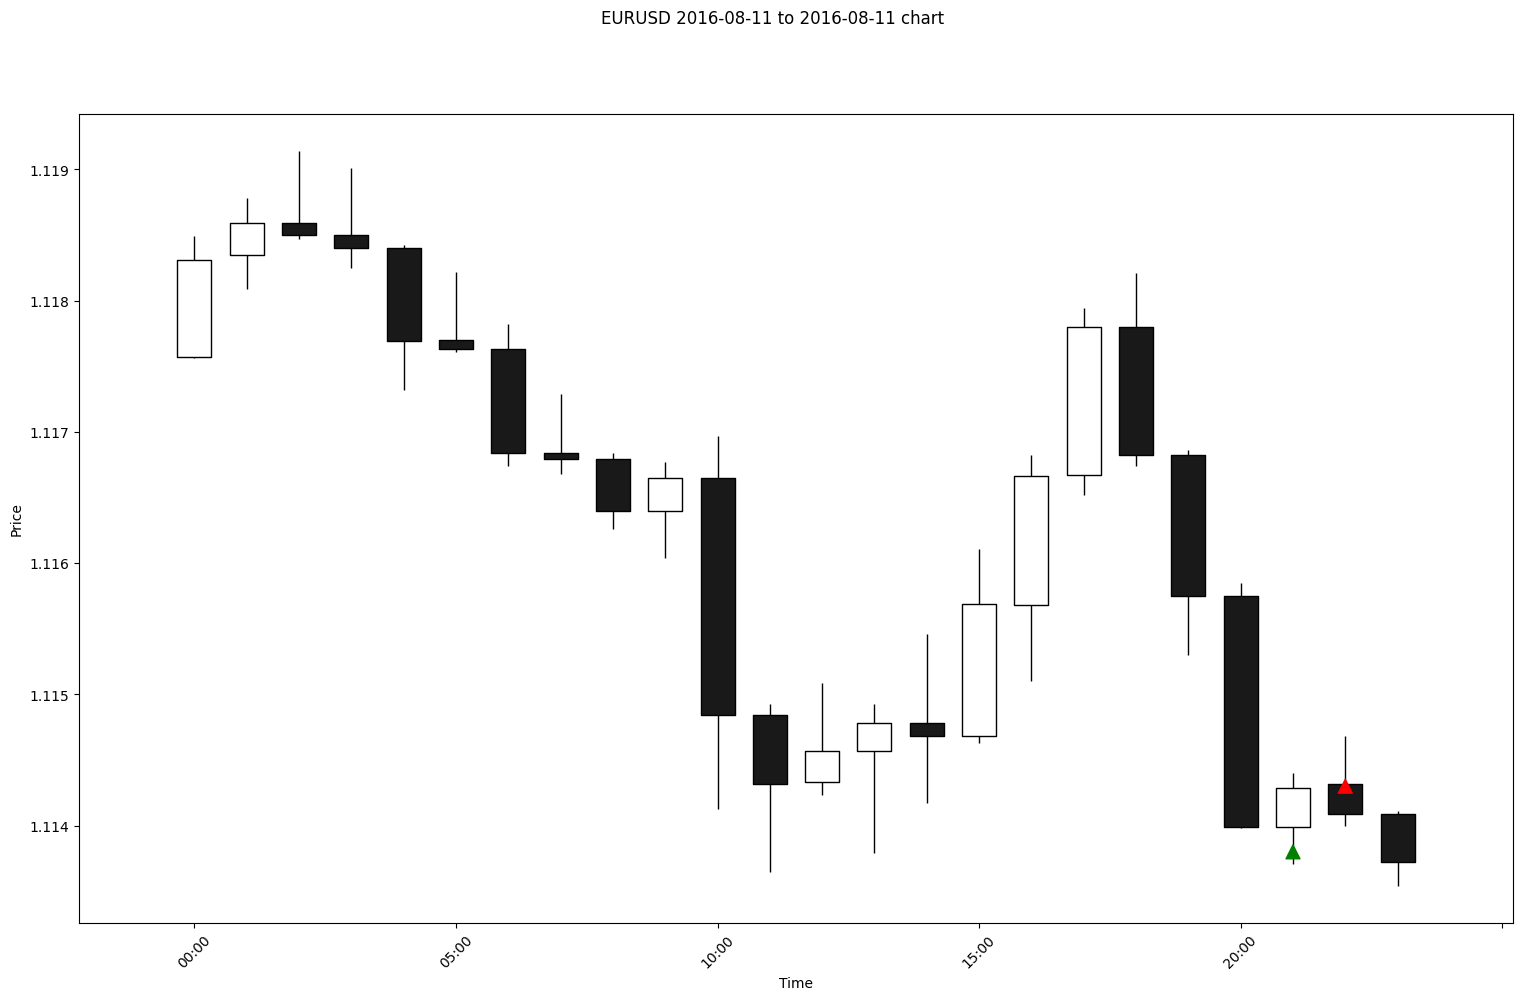

In [40]:
import matplotlib.pyplot as plt
import mplfinance
# filter to where the date and time is between 2024-03-07 16:36:00 and 2024.03.08 12:30:00
full_data_select_day = p_df[(p_df['Time'].dt.date >= datetime(2016, 8, 11).date()) & 
                                                       (p_df['Time'].dt.date <= datetime(2016, 8, 11).date())].set_index('Time')



fig, ax = plt.subplots()
mplfinance.plot(full_data_select_day, type='candle', ax=ax, volume=False, show_nontrading=False)
full_data_select_day_reset = full_data_select_day.reset_index()

if len(long_orders) > 0:
    # merge with long_orders
    full_data_select_day_reset = full_data_select_day_reset.merge(long_orders, how='left', on='Time')
elif len(short_orders) > 0:
    # merge with short_orders
    full_data_select_day_reset = full_data_select_day_reset.merge(short_orders, how='left', on='Time')
# Define color mapping
color_map = {'Entry': 'g', 'Exit': 'r'}
colors = full_data_select_day_reset['Entry/Exit'].fillna('Skip').map(color_map)

# Plot only non-NaN points
mask = full_data_select_day_reset['Entry/Exit'].notna()
ax.scatter(full_data_select_day_reset.index[mask], 
          full_data_select_day_reset['Entry/Exit Price'][mask], 
          c=colors[mask],
          s=100,
          marker='^',
          zorder=5)

# plot a horizontal line in green for the entry price at 1.12630, and the exit price at 1.110660
# ax.axhline(y=1.148443, color='g', linestyle='--')
# ax.axhline(y=1.112705, color='r', linestyle='--')
# ax.axhline(y=1.118060, color='r', linestyle='--')
ax.set_xlabel('Time')
ax.set_ylabel('Price')
# find the date of the first and last index
first_date = full_data_select_day_reset['Time'].iloc[0]
last_date = full_data_select_day_reset['Time'].iloc[-1]
fig.suptitle(f'EURUSD {first_date.date()} to {last_date.date()} chart')
# increase the size of the chart
fig.set_size_inches(18.5, 10.5)

plt.show()

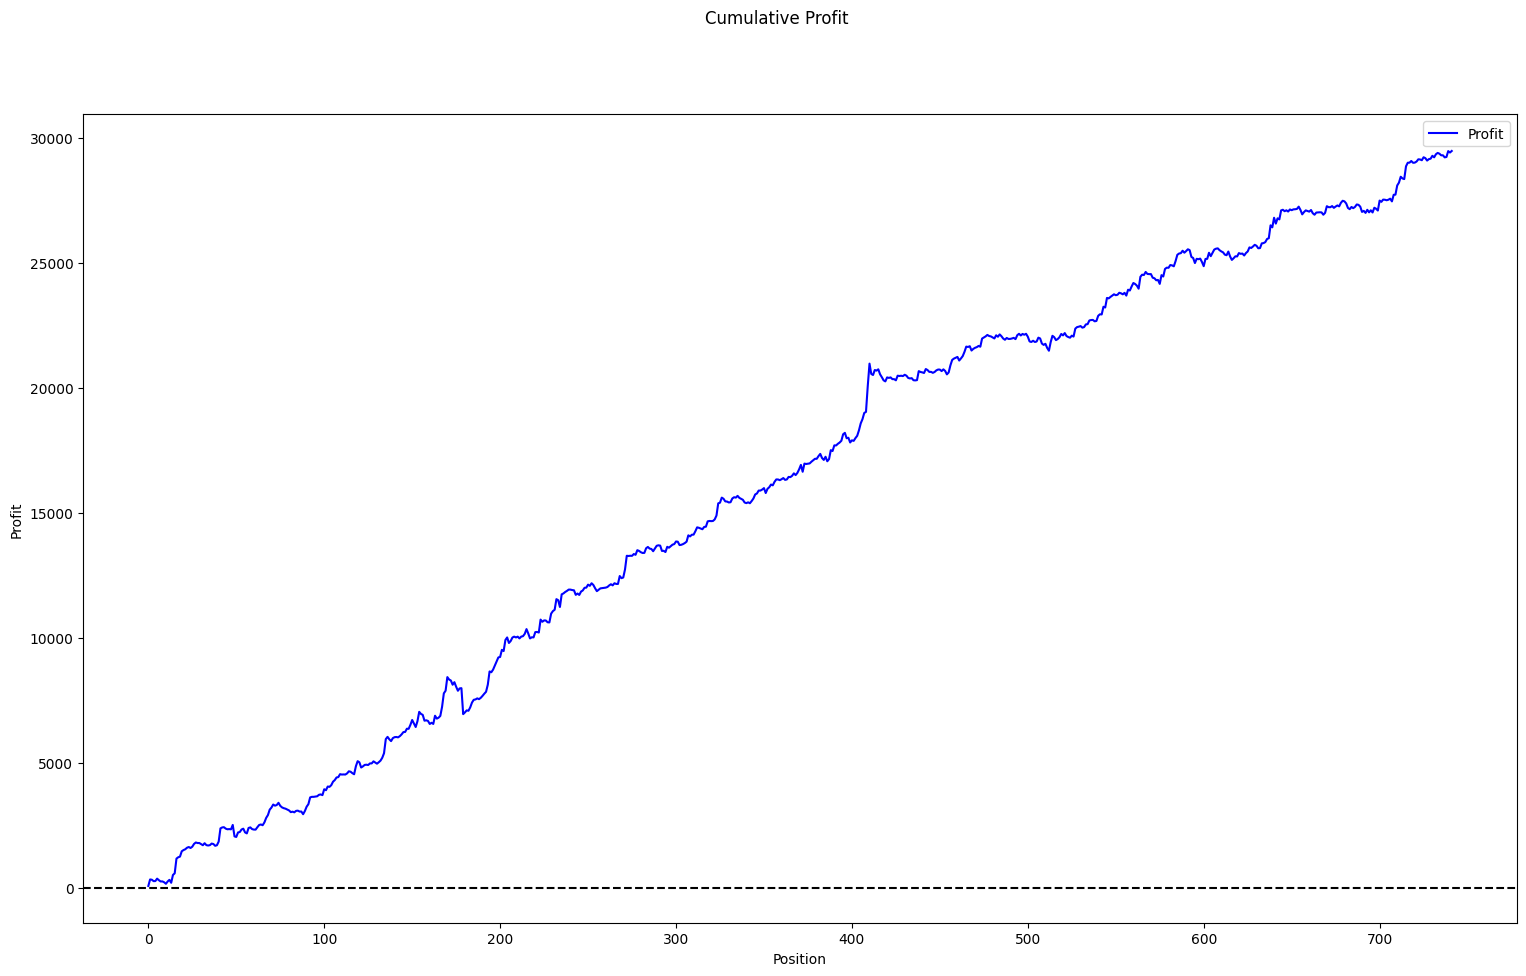

In [41]:
p_orders['cum_sum'] = p_orders['Profit'].cumsum()
# graph nova_profit_dollars and msolutions_profit_dollars over cum_position_count
fig, ax = plt.subplots()
ax.plot(p_orders['cum_sum'], label='Profit', color='blue')
# add in a line for 0 
ax.axhline(y=0, color='black', linestyle='--')
ax.set_xlabel('Position')
ax.set_ylabel('Profit')
fig.suptitle('Cumulative Profit')
# increase the size of the chart
fig.set_size_inches(18.5, 10.5)
# Add legend
ax.legend()
# Show the plot
plt.show()

In [104]:
print(p_df['Week_Nbr'].nunique())
p_orders['Profit'].sum()/p_df['Week_Nbr'].nunique()


420


79.42349148747789

In [42]:
p_orders[p_orders['Profit'] < 0]

,Id,Symbol,Type,Volume,Entry Time,Entry Price,Exit Time,Exit Price,Exit Balance,Exit Equity,Profit,Margin,Fee,Closed,cum_sum
2,740,EURUSD,Sell,1.0,2024-08-01 11:00:00+00:00,1.07843,2024-08-01 13:00:00+00:00,1.07848,429121.358654,392405.858654,-10.286024,1078.43,0.000053,True,335.979455
3,739,EURUSD,Sell,1.0,2024-07-29 12:00:00+00:00,1.08283,2024-07-29 13:00:00+00:00,1.08331,429131.644677,392411.144677,-56.557826,1082.83,0.000086,True,279.421629
6,736,EURUSD,Buy,1.0,2024-07-12 18:00:00+00:00,1.09064,2024-07-12 19:00:00+00:00,1.09015,429088.522701,392440.022701,-61.857514,1090.64,0.000129,True,317.243917
7,735,EURUSD,Buy,1.0,2024-07-03 11:00:00+00:00,1.07618,2024-07-03 12:00:00+00:00,1.07573,429150.380215,392452.880215,-51.596952,1076.18,0.000066,True,265.646965
9,733,EURUSD,Buy,1.0,2024-07-02 16:00:00+00:00,1.07323,2024-07-02 17:00:00+00:00,1.07298,429199.211497,392469.711497,-34.317487,1073.23,0.000093,True,234.095148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,11,EURUSD,Sell,1.0,2016-09-12 13:00:00+00:00,1.12208,2016-09-12 14:00:00+00:00,1.12257,400192.745093,399873.745093,-61.128030,1122.08,0.000121,True,29213.751009
734,8,EURUSD,Buy,1.0,2016-09-08 11:00:00+00:00,1.12749,2016-09-08 12:00:00+00:00,1.12729,400078.756111,399907.756111,-30.027266,1127.49,0.000100,True,29358.840755
735,7,EURUSD,Sell,1.0,2016-08-31 10:00:00+00:00,1.11411,2016-08-31 11:00:00+00:00,1.11466,400108.783377,399917.783377,-64.654417,1114.11,0.000097,True,29294.186338
737,5,EURUSD,Sell,1.0,2016-08-26 22:00:00+00:00,1.11905,2016-08-26 23:00:00+00:00,1.11974,400172.631015,399941.631015,-82.944991,1119.05,0.000139,True,29212.048126


In [44]:
len(p_orders[p_orders['Profit'] > 0]) / len(p_orders)

0.5929919137466307

# Optimization

In [14]:
search_space = {
    'timeframe': hp.choice('timeframe', ['15min', '1H', '2H', '3H', '4H']),  # Fixed value since it's a string - '4H', '1H'
    'atr_period': hp.quniform('atr_period', 7, 21, 1),
    'stop_loss_mult': hp.uniform('stop_loss_mult', 0.1, 3.5),  # Use hp.uniform for floats
    'take_profit_mult': hp.uniform('take_profit_mult', 0.1, 3.5),
}



In [18]:
with open(FOREX_DATA_PATH_15MIN, 'rb') as f:
    symbols_15min = pickle.load(f)

for pair in symbols_15min[0].keys():
    print('='*25)
    print(f'running {pair}')
    print('='*25)
    # convert symbols_15min to a pd.dataframe
    symbols_15min[1][pair].index = pd.to_datetime(symbols_15min[1][pair].index)
    # Create a partial function with the DataFrame pre-filled
    objective_with_df = partial(objective, full_data=symbols_15min[1][pair], currency_pair=pair)
    trials = Trials()
    best = fmin(fn=objective_with_df,
                space=search_space,
                algo=tpe.suggest,
                max_evals=2_000, # Number of evaluations of the objective function
                trials=trials,
                trials_save_file=(
                    f'{path_to_trading_folder}Indicator_backtesting/Indicator_search/{pair}_trials_search_DAX_pattern_'
                    f'{datetime.now().strftime("%Y%m%d_%H%M%S")}.pkl')
    )
    print("Best parameters:", best)

running USDCAD
balance: 402,216.30, Expectancy: -41.816986204625024, profit: 2,216.30, total orders: 53, both_hit: 0
balance: 402,211.01, Expectancy: -41.717165955116045, profit: 2,211.01, total orders: 53, both_hit: 0
balance: 402,233.65, Expectancy: -42.14435992081545, profit: 2,233.65, total orders: 53, both_hit: 0
balance: 402,216.16, Expectancy: -18.623161657686424, profit: 2,216.16, total orders: 119, both_hit: 0
balance: 401,510.05, Expectancy: -55.92780542722306, profit: 1,510.05, total orders: 27, both_hit: 0
balance: 402,201.47, Expectancy: -41.5372076832347, profit: 2,201.47, total orders: 53, both_hit: 0
balance: 401,463.43, Expectancy: -50.46304678441811, profit: 1,463.43, total orders: 29, both_hit: 0
balance: 395,296.88, Expectancy: 10.006628960048195, profit: -4,703.12, total orders: 470, both_hit: 0
balance: 402,035.39, Expectancy: -14.333728196535475, profit: 2,035.39, total orders: 142, both_hit: 2
balance: 395,808.60, Expectancy: 8.936885601337673, profit: -4,191.40

job exception: 'values' is not ordered, please explicitly specify the categories order by passing in a categories argument.



  0%|          | 0/2000 [00:03<?, ?trial/s, best loss=?]


TypeError: 'values' is not ordered, please explicitly specify the categories order by passing in a categories argument.

In [72]:
trials_latest_week = pickle.load(
    open(f'{path_to_trading_folder}Indicator_backtesting/Indicator_search/trials_search_DAX_pattern_20241214_090417.pkl', 'rb'))
trials_latest_week_all_results = trials_latest_week.results
# print(len(trials_latest_week_all_results),
# trials_latest_week_all_results[0])
best_hyperparameters_current_week = pd.DataFrame()
new_dict = {}

for idx, result in enumerate(trials_latest_week_all_results):
    new_dict['loss'] = result['loss']
    new_dict['status'] = result['status']
    new_dict['timeframe'] = result['parameters']['timeframe']
    new_dict['atr_period'] = result['parameters']['atr_period']
    new_dict['stop_loss_mult'] = result['parameters']['stop_loss_mult']
    new_dict['take_profit_mult'] = result['parameters']['take_profit_mult']

    new_row = pd.DataFrame(new_dict, index=[idx])
    best_hyperparameters_current_week = pd.concat([best_hyperparameters_current_week, new_row], axis=0)

best_hyperparameters_current_week



,loss,status,timeframe,atr_period,stop_loss_mult,take_profit_mult
0,inf,ok,2H,14.0,3.185374,2.856257
1,inf,ok,4H,11.0,2.197185,2.888887
2,inf,ok,3H,16.0,1.688763,2.533190
3,inf,ok,4H,7.0,1.920184,3.054792
4,inf,ok,2H,7.0,0.568829,3.398762
...,...,...,...,...,...,...
1995,-72.772586,ok,2H,16.0,3.002569,0.300741
1996,inf,ok,2H,14.0,2.702754,0.497764
1997,-53.061295,ok,2H,17.0,2.632838,0.153528
1998,-75.864006,ok,2H,15.0,2.961401,0.361338


In [73]:
positive = best_hyperparameters_current_week[best_hyperparameters_current_week['loss'] < 0].copy()
positive = positive.drop(columns=['status'])
positive['loss'] = positive['loss'] * -1

# Optimization Report

In [74]:
# Create a profile report for your dataframe
profile = ProfileReport(positive, title="Data Profiling Report")

# Generate the report
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [77]:
positive.sort_values(by='loss', ascending=False).head(10)

,loss,timeframe,atr_period,stop_loss_mult,take_profit_mult
894,77.026353,2H,13.0,3.106864,0.369827
1618,76.854335,2H,14.0,3.060663,0.369410
1297,76.705599,2H,14.0,3.000689,0.368280
819,76.642648,2H,16.0,1.956495,0.364538
1900,76.629729,2H,16.0,2.865110,0.366273
331,76.616734,2H,15.0,2.961878,0.367087
10,76.599403,2H,17.0,3.455503,0.366634
1725,76.570525,2H,15.0,2.505085,0.372708
200,76.567532,2H,15.0,2.760076,0.373552
1322,76.562791,2H,14.0,3.179803,0.366645


# Best parameters found

In [100]:
p = positive.sort_values(by='loss', ascending=False).head(1).to_dict(orient='records')[0]
p_all = objective(p, full_data)
p_orders = p_all['state']
full_df = p_all['full_df']

balance: 433,357.87, Expectancy: -76.8614433749786, profit: 33,357.87, total orders: 434, both_hit: 0


In [101]:
p_orders.loc[:, 'Week_Nbr'] = (
    p_orders['Entry Time'].dt.year.astype(str) + 
    p_orders['Entry Time'].dt.isocalendar().week.astype(str)
)
# group by week and calculate the average profit, the number of trades, and the number of profitable trades
p_orders.groupby('Week_Nbr').agg({'Profit': 'sum', 'Id': 'count'}).agg({'Profit': 'mean'})

Profit    128.299486
dtype: float64

In [81]:
p_orders

,Id,Symbol,Type,Volume,Entry Time,Entry Price,Exit Time,Exit Price,Exit Balance,Exit Equity,Profit,Margin,Fee,Closed,Week_Nbr
0,434,EURUSD,Sell,1.0,2024-08-08 16:00:00+00:00,1.09002,2024-08-08 18:00:00+00:00,1.090790,433206.763967,395462.988229,-84.308825,1090.02,0.000073,True,202432
1,433,EURUSD,Sell,1.0,2024-08-06 14:00:00+00:00,1.09070,2024-08-06 16:00:00+00:00,1.091560,433291.072792,395470.297054,-97.851905,1090.70,0.000119,True,202432
2,432,EURUSD,Buy,1.0,2024-08-02 16:00:00+00:00,1.08917,2024-08-02 18:00:00+00:00,1.091920,433388.924698,395482.148960,269.092567,1089.17,0.000059,True,202431
3,431,EURUSD,Sell,1.0,2024-08-01 12:00:00+00:00,1.07833,2024-08-01 14:00:00+00:00,1.079490,433119.832131,395488.056393,-125.857280,1078.33,0.000099,True,202431
4,430,EURUSD,Sell,1.0,2024-07-23 12:00:00+00:00,1.08717,2024-07-23 14:00:00+00:00,1.085680,433245.689411,395497.913673,140.493022,1087.17,0.000085,True,202430
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,5,EURUSD,Sell,1.0,2016-08-26 22:00:00+00:00,1.11905,2016-08-27 00:00:00+00:00,1.119510,400840.971992,399944.508206,-57.093663,1119.05,0.000111,True,201634
430,4,EURUSD,Sell,1.0,2016-08-24 16:00:00+00:00,1.12597,2016-08-24 18:00:00+00:00,1.124780,400898.065654,399955.601869,109.801087,1125.97,0.000092,True,201634
431,3,EURUSD,Buy,1.0,2016-08-22 18:00:00+00:00,1.13223,2016-08-22 20:00:00+00:00,1.131770,400788.264568,399964.800782,-57.558571,1132.23,0.000116,True,201634
432,2,EURUSD,Buy,1.0,2016-08-16 12:00:00+00:00,1.12584,2016-08-16 14:00:00+00:00,1.130089,400845.823139,399976.359353,412.368500,1125.84,0.000126,True,201633


In [102]:
# calculate the win rate:
win_rate = len(p_orders[p_orders['Profit'] > 0]) / len(p_orders)
win_rate

0.6428571428571429

In [87]:
p_orders_select_day = p_orders.loc[(p_orders['Entry Time'].dt.date >= datetime(2016, 8, 22).date()) &
                                   (p_orders['Entry Time'].dt.date <= datetime(2016, 8, 22).date()),
                                     ['Entry Time', 'Exit Time', 'Entry Price', 'Exit Price', 'Type']].copy()
# Create entry rows
entries = p_orders_select_day[['Type', 'Entry Time', 'Entry Price']].rename(columns={'Entry Time': 'Time', 'Entry Price': 'Price'})
entries['Entry/Exit'] = 'Entry'
# Create exit rows 
exits = p_orders_select_day[['Type', 'Exit Time', 'Exit Price']].rename(columns={'Exit Time': 'Time', 'Exit Price': 'Price'})
exits['Entry/Exit'] = 'Exit'

# Combine and sort by time
p_orders_select_day = pd.concat([entries, exits]).sort_values('Time').reset_index(drop=True)

long_orders = p_orders_select_day[p_orders_select_day['Type'] == 'Buy'].copy()
short_orders = p_orders_select_day[p_orders_select_day['Type'] == 'Sell'].copy()
long_orders = long_orders.rename(columns={'Price': 'Long Entry/Exit Price',
                                          'Entry/Exit': 'Long Entry/Exit'}).drop(columns=['Type'])
short_orders = short_orders.rename(columns={'Price': 'Short Entry/Exit Price',
                                            'Entry/Exit': 'Short Entry/Exit'}).drop(columns=['Type'])
long_orders

,Time,Long Entry/Exit Price,Long Entry/Exit
0,2016-08-22 18:00:00+00:00,1.13223,Entry
1,2016-08-22 20:00:00+00:00,1.13177,Exit


In [88]:
short_orders

,Time,Short Entry/Exit Price,Short Entry/Exit


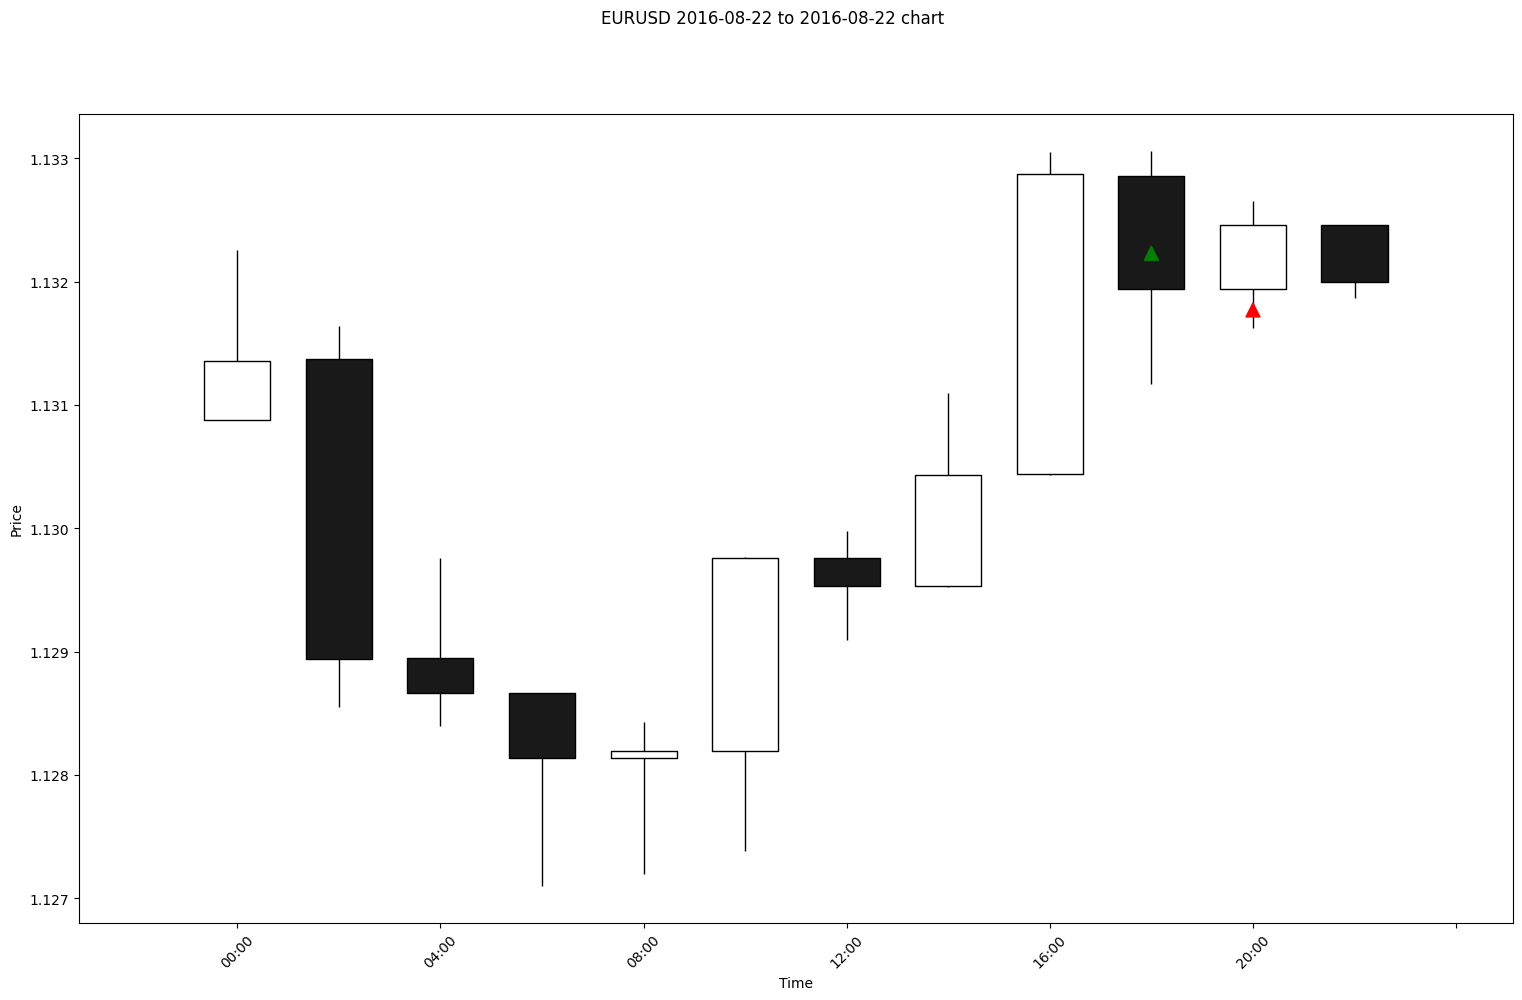

In [89]:
import matplotlib.pyplot as plt
%matplotlib inline
import mplfinance
# filter to where the date and time is between 2024-03-07 16:36:00 and 2024.03.08 12:30:00
full_data_select_day = full_df[(full_df['Time'].dt.date >= datetime(2016, 8, 22).date()) & 
                                                       (full_df['Time'].dt.date <= datetime(2016, 8, 22).date())].set_index('Time')



fig, ax = plt.subplots()
mplfinance.plot(full_data_select_day, type='candle', ax=ax, volume=False, show_nontrading=False)
full_data_select_day_reset = full_data_select_day.reset_index()

if len(long_orders) > 0:
    # merge with long_orders
    full_data_select_day_reset = full_data_select_day_reset.merge(long_orders, how='left', on='Time')
    # Define color mapping
    color_map = {'Entry': 'g', 'Exit': 'r'}
    colors = full_data_select_day_reset['Long Entry/Exit'].fillna('Skip').map(color_map)

    # Plot only non-NaN points
    mask = full_data_select_day_reset['Long Entry/Exit'].notna()
    ax.scatter(full_data_select_day_reset.index[mask], 
            full_data_select_day_reset['Long Entry/Exit Price'][mask], 
            c=colors[mask],
            s=100,
            marker='^', zorder=5) #, zorder=5
if len(short_orders) > 0:
    # merge with short_orders
    full_data_select_day_reset = full_data_select_day_reset.merge(short_orders, how='left', on='Time')
    # Define color mapping
    color_map = {'Entry': 'g', 'Exit': 'r'}
    colors = full_data_select_day_reset['Short Entry/Exit'].fillna('Skip').map(color_map)

    # Plot only non-NaN points
    mask = full_data_select_day_reset['Short Entry/Exit'].notna()
    ax.scatter(full_data_select_day_reset.index[mask], 
            full_data_select_day_reset['Short Entry/Exit Price'][mask], 
            c=colors[mask],
            s=100,
            marker='o', zorder=6) #, zorder=5
ax.scatter(full_data_select_day_reset.index, 
        full_data_select_day_reset['stop_level'], 
        s=30,
        marker='s', zorder=7)

# plot a horizontal line in green for the entry price at 1.12630, and the exit price at 1.110660
# ax.axhline(y=1.148443, color='g', linestyle='--')
# ax.axhline(y=1.11438, color='r', linestyle='--')
# ax.axhline(y=1.118060, color='r', linestyle='--')
ax.set_xlabel('Time')
ax.set_ylabel('Price')
# find the date of the first and last index
first_date = full_data_select_day_reset['Time'].iloc[0]
last_date = full_data_select_day_reset['Time'].iloc[-1]
fig.suptitle(f'EURUSD {first_date.date()} to {last_date.date()} chart')
# increase the size of the chart
fig.set_size_inches(18.5, 10.5)

plt.show()

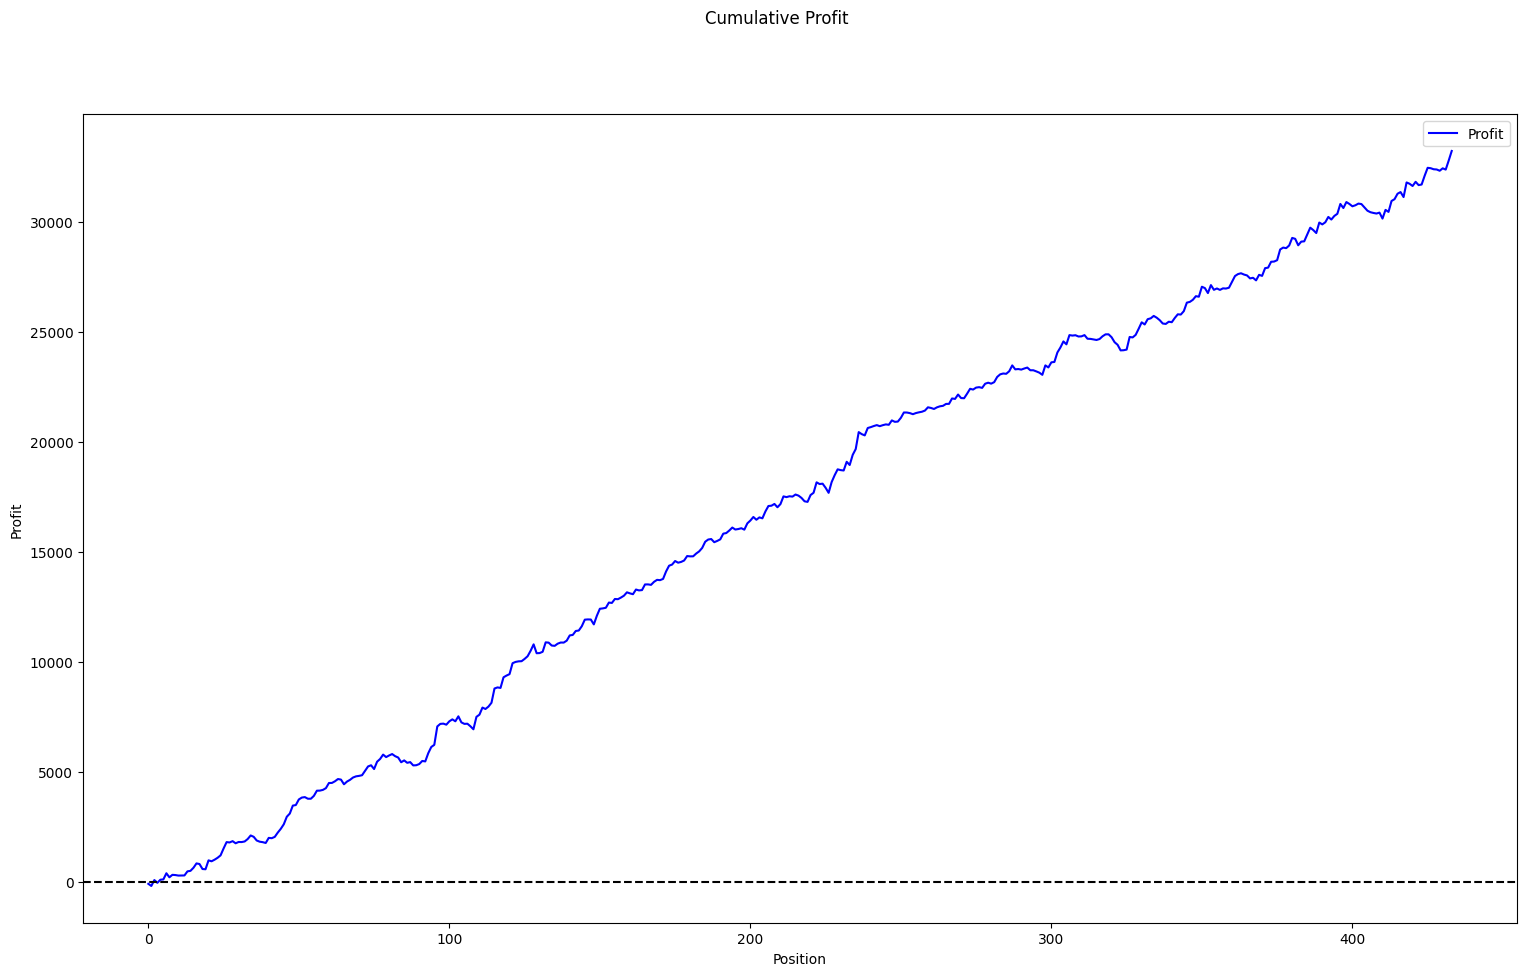

In [83]:
p_orders['cum_sum'] = p_orders['Profit'].cumsum()
# graph nova_profit_dollars and msolutions_profit_dollars over cum_position_count
fig, ax = plt.subplots()
ax.plot(p_orders['cum_sum'], label='Profit', color='blue')
# add in a line for 0 
ax.axhline(y=0, color='black', linestyle='--')
ax.set_xlabel('Position')
ax.set_ylabel('Profit')
fig.suptitle('Cumulative Profit')
# increase the size of the chart
fig.set_size_inches(18.5, 10.5)
# Add legend
ax.legend()
# Show the plot
plt.show()

# Monthly Analysis

In [106]:
p_orders_sel = p_orders[['Entry Time', 'Profit']].copy()
p_orders_sel['Entry Time'] = pd.to_datetime(p_orders_sel['Entry Time'])
p_orders_sel.set_index('Entry Time', inplace=True)
p_orders_sel.sort_index(inplace=True)
# resample for monthly
p_orders_monthly = p_orders_sel.resample('M').sum()
print(p_orders_monthly.Profit.mean(),
      p_orders_monthly.Profit.min(),
      p_orders_monthly.Profit.max())

343.8955301519661 -443.9821973995627 1652.8944524174613


# Daily Analysis

In [108]:
# resample for monthly
p_orders_daily = p_orders_sel.resample('D').sum()
print(p_orders_daily.Profit.mean(),
      p_orders_daily.Profit.min(),
      p_orders_daily.Profit.max())

11.443521929585152 -402.8789659374378 1065.9592652153906


# Last Month

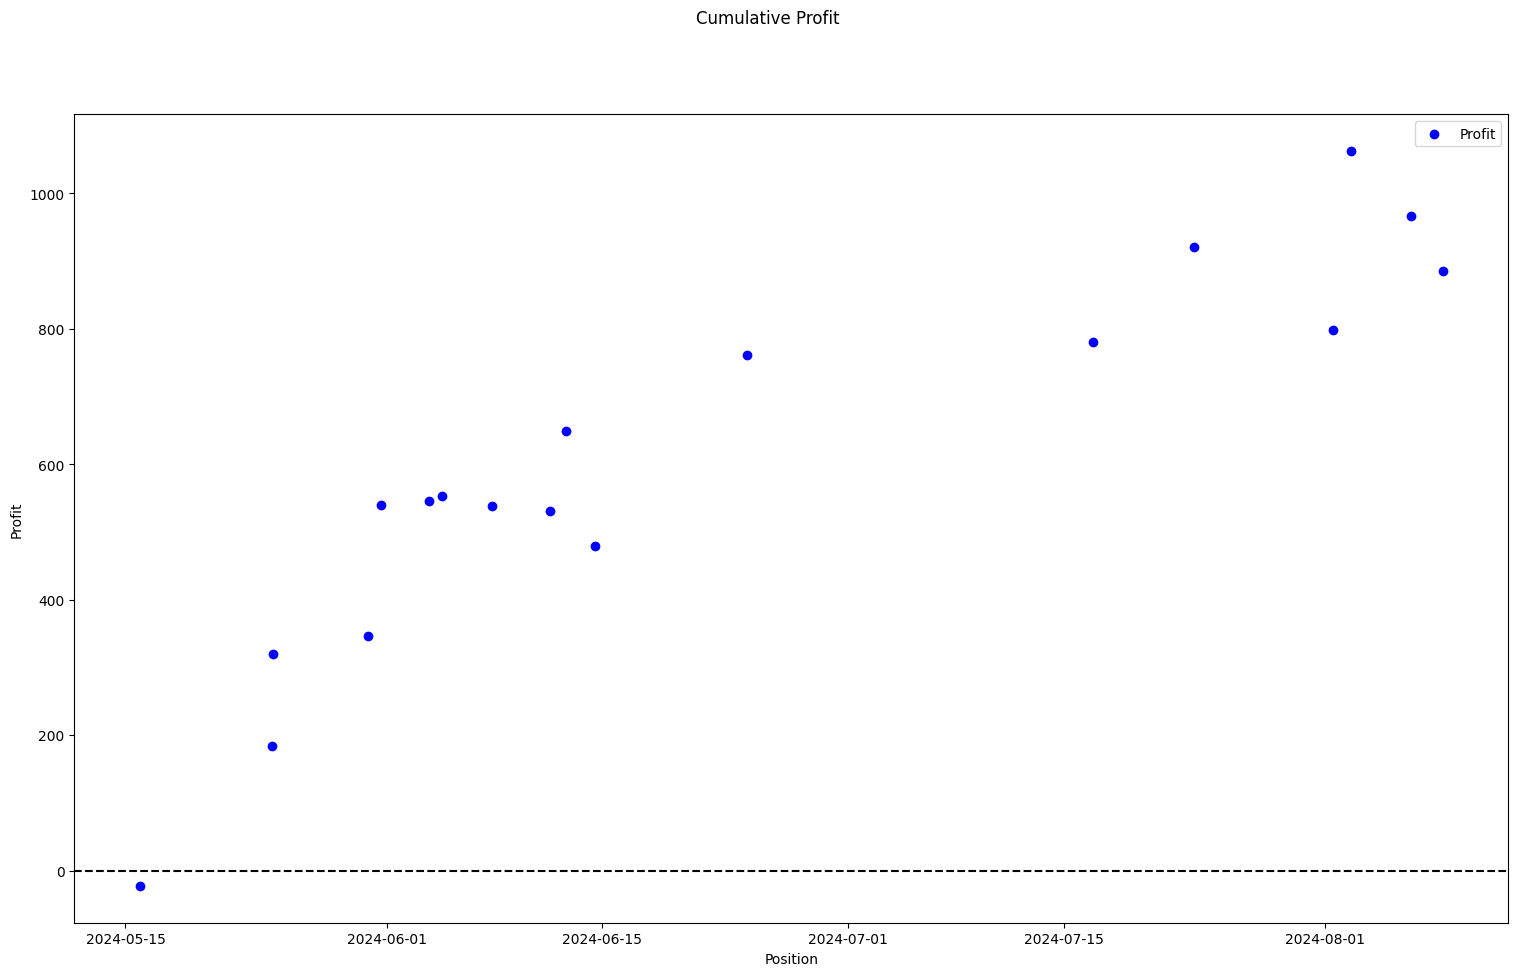

In [115]:
last_month = p_orders_sel[p_orders_sel.index >= p_orders_sel.index.max() - relativedelta(months=3)].copy()
last_month['cum_sum'] = last_month['Profit'].cumsum()
# graph nova_profit_dollars and msolutions_profit_dollars over cum_position_count
fig, ax = plt.subplots()
ax.scatter(last_month.index, last_month['cum_sum'], label='Profit', color='blue')
# add in a line for 0 
ax.axhline(y=0, color='black', linestyle='--')
ax.set_xlabel('Position')
ax.set_ylabel('Profit')
fig.suptitle('Cumulative Profit')
# increase the size of the chart
fig.set_size_inches(18.5, 10.5)
# Add legend
ax.legend()
# Show the plot
plt.show()

In [ ]:
last_month = p_orders_sel[p_orders_sel.index >= p_orders_sel.index.max() - relativedelta(months=1)]
# plot the last month in the dataset with orders
p_orders_select_day = p_orders.loc[(p_orders['Entry Time'].dt.date >= datetime(2016, 8, 22).date()) &
                                   (p_orders['Entry Time'].dt.date <= datetime(2016, 8, 22).date()),
                                     ['Entry Time', 'Exit Time', 'Entry Price', 'Exit Price', 'Type']].copy()
# Create entry rows
entries = p_orders_select_day[['Type', 'Entry Time', 'Entry Price']].rename(columns={'Entry Time': 'Time', 'Entry Price': 'Price'})
entries['Entry/Exit'] = 'Entry'
# Create exit rows 
exits = p_orders_select_day[['Type', 'Exit Time', 'Exit Price']].rename(columns={'Exit Time': 'Time', 'Exit Price': 'Price'})
exits['Entry/Exit'] = 'Exit'

# Combine and sort by time
p_orders_select_day = pd.concat([entries, exits]).sort_values('Time').reset_index(drop=True)

long_orders = p_orders_select_day[p_orders_select_day['Type'] == 'Buy'].copy()
short_orders = p_orders_select_day[p_orders_select_day['Type'] == 'Sell'].copy()
long_orders = long_orders.rename(columns={'Price': 'Long Entry/Exit Price',
                                          'Entry/Exit': 'Long Entry/Exit'}).drop(columns=['Type'])
short_orders = short_orders.rename(columns={'Price': 'Short Entry/Exit Price',
                                            'Entry/Exit': 'Short Entry/Exit'}).drop(columns=['Type'])



In [76]:
from backtesting import Strategy
from backtesting import Backtest
df_resampled = df_with_signals[~df_with_signals['atr'].isnull()].copy()
def SIGNAL():
    return df_resampled.signal

class MyStrat(Strategy):
    mysize = 0.1  # Trade size
    slperc = 0.04
    tpperc = 0.02

    def init(self):
        super().init()
        self.signal1 = self.I(SIGNAL)  # Assuming SIGNAL is a function that returns signals

    def next(self):
        super().next()
         
        if self.signal1 == 1: # and not self.position
            # Open a new long position with calculated SL and TP
            current_close = self.data.Close[-1]
            sl = current_close - self.data.stop_distance  # SL at 4% below the close price
            tp = current_close + self.data.profit_distance  # TP at 2% above the close price
            self.buy(size=self.mysize, sl=sl, tp=tp)

        elif self.signal1 == -1:
            # Open a new short position, setting SL based on a strategy-specific requirement
            current_close = self.data.Close[-1]
            sl = current_close + self.data.stop_distance  # SL at 4% below the close price
            tp = current_close - self.data.profit_distance  # TP at 2% above the close price
            self.sell(size=self.mysize, sl=sl, tp=tp)
bt = Backtest(df_resampled, MyStrat, cash=100_000, hedging=True, commission=0.0002)    
stats = bt.run()
# bt.plot()

In [77]:
import pandas as pd

closed_trades = stats._strategy.closed_trades

trades_data = [{
    'Entry Time': trade.entry_time,
    'Exit Time': trade.exit_time,
    'Entry Price': trade.entry_price,
    'Exit Price': trade.exit_price,
    'Position': 'Long' if trade.size > 0 else 'Short',
    'Size': abs(trade.size),
    'PnL': trade.pl,
    'PnL %': trade.pl_pct
} for trade in closed_trades]

trades_df = pd.DataFrame(trades_data)
trades_df

,Entry Time,Exit Time,Entry Price,Exit Price,Position,Size,PnL,PnL %
0,2023-08-17 05:00:00,2023-08-25 10:00:00,1.086363,1.077335,Short,7464,67.382633,0.008310
1,2023-08-14 23:00:00,2023-08-25 10:00:00,1.090062,1.077485,Short,8252,103.784942,0.011538
2,2023-08-29 10:00:00,2023-08-29 19:00:00,1.080644,1.086005,Short,7518,-40.305291,-0.004961
3,2023-08-25 15:00:00,2023-08-29 20:00:00,1.080486,1.087255,Long,8356,56.561313,0.006265
4,2023-08-31 14:00:00,2023-09-05 09:00:00,1.087113,1.075830,Short,7468,84.257964,0.010378
...,...,...,...,...,...,...,...,...
192,2024-07-29 13:00:00,2024-08-02 16:00:00,1.083483,1.090220,Short,7665,-51.637112,-0.006218
193,2024-08-06 11:00:00,2024-08-09 23:00:00,1.092451,1.091860,Short,6833,4.041487,0.000541
194,2024-08-02 18:00:00,2024-08-09 23:00:00,1.092458,1.091860,Long,7592,-4.543417,-0.000548
195,2024-08-02 17:00:00,2024-08-09 23:00:00,1.090778,1.091860,Long,8449,9.140872,0.000992


In [78]:
stats

Start                     2023-08-10 12:00:00
End                       2024-08-09 23:00:00
Duration                    365 days 11:00:00
Exposure Time [%]                   99.054032
Equity Final [$]                100414.955005
Equity Peak [$]                  102052.21384
Return [%]                           0.414955
Buy & Hold Return [%]                -0.94278
Return (Ann.) [%]                    0.400618
Volatility (Ann.) [%]                  1.3125
Sharpe Ratio                         0.305233
Sortino Ratio                        0.473363
Calmar Ratio                         0.243237
Max. Drawdown [%]                   -1.647029
Avg. Drawdown [%]                   -0.083835
Max. Drawdown Duration      225 days 12:00:00
Avg. Drawdown Duration        4 days 22:00:00
# Trades                                  197
Win Rate [%]                        53.807107
Best Trade [%]                       2.343164
Worst Trade [%]                     -2.512875
Avg. Trade [%]                    